<a href="https://colab.research.google.com/github/SABBiR1107/marketing-campaign-performance-analysis-with-python/blob/main/tech_advertising_campaigns_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

sns.set_theme(style="whitegrid")

In [17]:
# Load Dataset
df = pd.read_csv("/content/tech_advertising_campaigns_dataset.csv")
df.head()

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,creative_age_days,target_audience_age,target_audience_gender,audience_interest_category,income_bracket,purchase_intent_score,retargeting_flag,start_date,quarter,day_of_week,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,72,45-54,Female,Shoppers,<$50K,Medium,False,2024-03-06,1,Wednesday,18,34,5,2.230,66329,402,2,896.460,289.670,67.750,70,2.000,E-commerce,High,0.606,2.230,0.498,448.230,0.320,-606.790
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,62,65+,Female,Business Professionals,$50K-$100K,Medium,False,2024-01-26,1,Friday,6,22,5,2.480,50094,467,5,1158.160,1728.200,63.730,105,2.740,Finance,Medium,0.932,2.480,1.071,231.630,1.490,570.040
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,79,65+,Male,Tech Enthusiasts,<$50K,High,False,2025-05-15,2,Thursday,1,32,4,3.880,10842,112,6,434.560,2903.260,31.930,149,3.970,Healthcare,Low,1.033,3.880,5.357,72.430,6.680,2468.700
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,57,35-44,All,Shoppers,<$50K,Low,False,2024-07-21,3,Sunday,7,32,4,8.290,7820,123,3,1019.670,502.280,65.520,147,2.490,Education,Medium,1.573,8.290,2.439,339.890,0.490,-517.390
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,17,25-34,Female,Students,$100K-$200K,Low,False,2025-03-09,1,Sunday,17,52,7,1.410,21436,302,0,425.820,0.000,68.950,81,3.040,SaaS,Low,1.409,1.410,0.000,0.000,0.000,-425.820


In [14]:
# Check info and shape
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   campaign_id                   10000 non-null  object 
 1   campaign_objective            10000 non-null  object 
 2   platform                      10000 non-null  object 
 3   ad_placement                  10000 non-null  object 
 4   device_type                   10000 non-null  object 
 5   operating_system              10000 non-null  object 
 6   creative_format               10000 non-null  object 
 7   creative_size                 10000 non-null  object 
 8   ad_copy_length                10000 non-null  object 
 9   has_call_to_action            10000 non-null  bool   
 10  creative_emotion              10000 non-null  object 
 11  creative_age_days             10000 non-null  int64  
 12  target_audience_age           10000 non-null  object 
 13  ta

(10000, 41)

In [18]:
# Dataset Basic Overview
df.describe().T

,count,mean,std,min,25%,50%,75%,max
creative_age_days,10000.000,45.374,26.171,1.000,22.000,45.000,68.000,90.000
quarter,10000.000,2.419,1.132,1.000,1.000,2.000,3.000,4.000
hour_of_day,10000.000,11.482,6.932,0.000,5.000,12.000,18.000,23.000
campaign_day,10000.000,45.430,26.071,1.000,23.000,45.000,68.000,90.000
quality_score,10000.000,5.527,1.554,1.000,4.000,6.000,7.000,10.000
actual_cpc,10000.000,3.290,2.454,0.300,1.510,2.430,4.530,16.030
impressions,10000.000,70539.223,91339.733,5000.000,16958.500,37469.500,83213.750,500000.000
clicks,10000.000,1526.436,2412.165,10.000,290.000,718.000,1746.000,40000.000
conversions,10000.000,65.569,183.405,0.000,5.000,16.000,55.000,5384.000
ad_spend,10000.000,4345.566,6917.481,8.690,666.308,1895.670,4996.160,49999.680


In [20]:
# Checking Missing Values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0


In [25]:
# Check Duplicate
df.duplicated().sum()

np.int64(0)

In [26]:
# Convertig Data Type

df['start_date'] = pd.to_datetime(df['start_date'])

df['has_call_to_action_label'] = df['has_call_to_action'].map({True: 1, False: 0})

df['retargeting_label'] = df['retargeting_flag'].map({True: 1, False: 0})

print(df.dtypes)

campaign_id                             object
campaign_objective                      object
platform                                object
ad_placement                            object
device_type                             object
operating_system                        object
creative_format                         object
creative_size                           object
ad_copy_length                          object
has_call_to_action                        bool
creative_emotion                        object
creative_age_days                        int64
target_audience_age                     object
target_audience_gender                  object
audience_interest_category              object
income_bracket                          object
purchase_intent_score                   object
retargeting_flag                          bool
start_date                      datetime64[ns]
quarter                                  int64
day_of_week                             object
hour_of_day  

In [35]:
# Create additional Features
df['month'] = df['start_date'].dt.month
df['month_name'] = df['start_date'].dt.month_name()
df['year'] = df['start_date'].dt.year


df['profit_status'] = np.where(df['profit'] > 0, 'profitable', 'unprofitable')
df['roas_status'] = pd.cut(
    df['ROAS'],
    bins=[-np.inf, 1, 2, 3, 4, np.inf],
    labels=['Poor','Average','Good','Very Good','Excellent']
)
df.head()

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,creative_age_days,target_audience_age,target_audience_gender,audience_interest_category,income_bracket,purchase_intent_score,retargeting_flag,start_date,quarter,day_of_week,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit,has_call_to_action_label,retargeting_label,month,month_name,year,profit_status,roas_status
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,72,45-54,Female,Shoppers,<$50K,Medium,False,2024-03-06,1,Wednesday,18,34,5,2.230,66329,402,2,896.460,289.670,67.750,70,2.000,E-commerce,High,0.606,2.230,0.498,448.230,0.320,-606.790,0,0,3,March,2024,unprofitable,Poor
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,62,65+,Female,Business Professionals,$50K-$100K,Medium,False,2024-01-26,1,Friday,6,22,5,2.480,50094,467,5,1158.160,1728.200,63.730,105,2.740,Finance,Medium,0.932,2.480,1.071,231.630,1.490,570.040,1,0,1,January,2024,profitable,Average
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,79,65+,Male,Tech Enthusiasts,<$50K,High,False,2025-05-15,2,Thursday,1,32,4,3.880,10842,112,6,434.560,2903.260,31.930,149,3.970,Healthcare,Low,1.033,3.880,5.357,72.430,6.680,2468.700,0,0,5,May,2025,profitable,Excellent
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,57,35-44,All,Shoppers,<$50K,Low,False,2024-07-21,3,Sunday,7,32,4,8.290,7820,123,3,1019.670,502.280,65.520,147,2.490,Education,Medium,1.573,8.290,2.439,339.890,0.490,-517.390,0,0,7,July,2024,unprofitable,Poor
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,17,25-34,Female,Students,$100K-$200K,Low,False,2025-03-09,1,Sunday,17,52,7,1.410,21436,302,0,425.820,0.000,68.950,81,3.040,SaaS,Low,1.409,1.410,0.000,0.000,0.000,-425.820,0,0,3,March,2025,unprofitable,Poor


In [38]:
from numpy._core import numeric
# Seperate Numaric and Categorical Columns

num_cols = df.select_dtypes(include=np.number).columns.to_list
car_cols = df.select_dtypes(include='object').columns.to_list

print(num_cols)
print(car_cols)

<bound method IndexOpsMixin.tolist of Index(['creative_age_days', 'quarter', 'hour_of_day', 'campaign_day',
       'quality_score', 'actual_cpc', 'impressions', 'clicks', 'conversions',
       'ad_spend', 'revenue', 'bounce_rate', 'avg_session_duration_seconds',
       'pages_per_session', 'CTR', 'CPC', 'conversion_rate', 'CPA', 'ROAS',
       'profit', 'has_call_to_action_label', 'retargeting_label', 'month',
       'year'],
      dtype='object')>
<bound method IndexOpsMixin.tolist of Index(['campaign_id', 'campaign_objective', 'platform', 'ad_placement',
       'device_type', 'operating_system', 'creative_format', 'creative_size',
       'ad_copy_length', 'creative_emotion', 'target_audience_age',
       'target_audience_gender', 'audience_interest_category',
       'income_bracket', 'purchase_intent_score', 'day_of_week',
       'industry_vertical', 'budget_tier', 'month_name', 'profit_status'],
      dtype='object')>


# Univariate Analysis

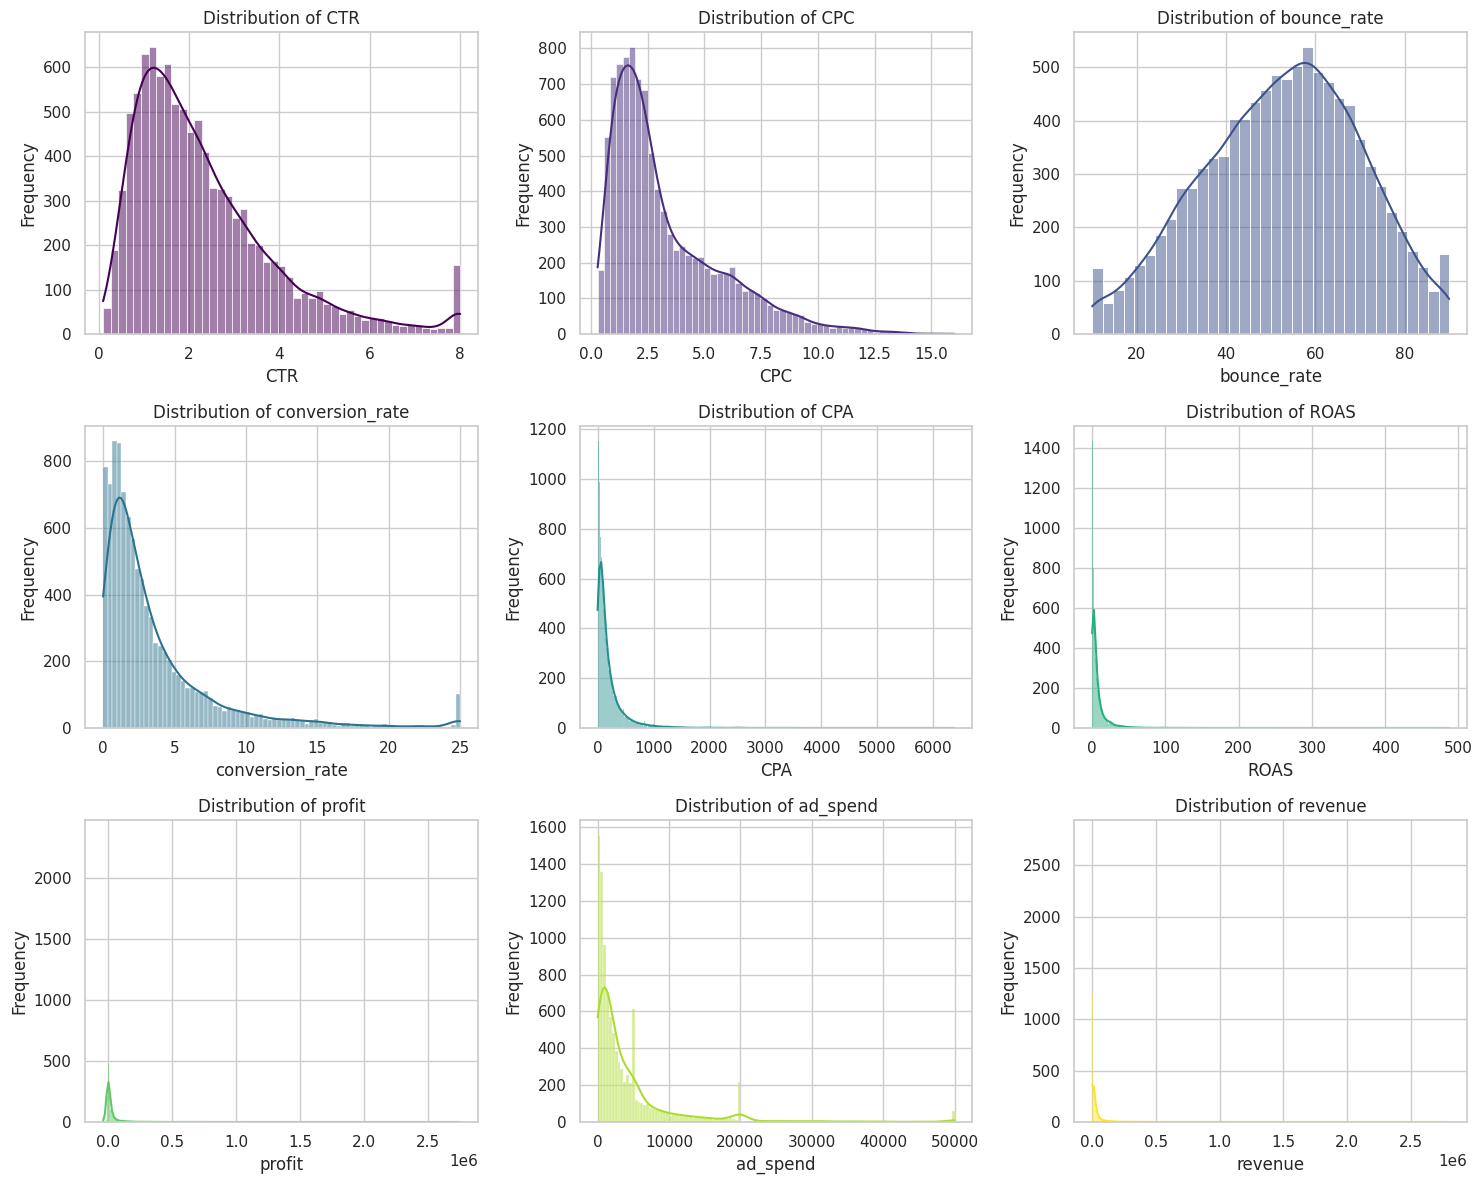

In [45]:
import matplotlib.cm as cm

# Distribution plots for main KPIs
kpi_cols =['CTR', "CPC", 'bounce_rate', "conversion_rate", "CPA", 'ROAS', 'profit', "ad_spend", "revenue"]

# Calculate grid dimensions for subplots
n_cols = 3  # You can adjust this number
n_rows = (len(kpi_cols) + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Generate a color map for the plots
colors = cm.viridis(np.linspace(0, 1, len(kpi_cols)))

for i, col in enumerate(kpi_cols):
  sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i])
  axes[i].set_title(f'Distribution of {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# KPI Overview

In [49]:
# Overall Business KPIs

summary_kpis = {
    "Total Campaigns": df["campaign_id"].nunique(),
    "Total Impressions": df["impressions"].sum(),
    "Total Clicks": df["clicks"].sum(),
    "Total Conversions": df["conversions"].sum(),
    "Total Ad Spend": df["ad_spend"].sum(),
    "Total Revenue": df["revenue"].sum(),
    "Total Profit": df["profit"].sum(),
    "Average CTR": df["CTR"].mean(),
    "Average CPC": df["CPC"].mean(),
    "Average Conversion Rate": df["conversion_rate"].mean(),
    "Average CPA": df["CPA"].replace([np.inf, -np.inf], np.nan).mean(),
    "Average ROAS": df["ROAS"].mean()
}

kpi_df = pd.DataFrame(summary_kpis.items(), columns=["Metric", "Value"])
kpi_df

,Metric,Value
0,Total Campaigns,10000.000
1,Total Impressions,705392230.000
2,Total Clicks,15264361.000
3,Total Conversions,655688.000
4,Total Ad Spend,43455661.790
5,Total Revenue,284157706.470
6,Total Profit,240702044.680
7,Average CTR,2.314
8,Average CPC,3.290
9,Average Conversion Rate,3.644


# Group Analysis

In [53]:
# Platfrom Performance

platform_perf = df.groupby("platform").agg(
    campaigns=("campaign_id", "nunique"),
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    ad_spend=("ad_spend", "sum"),
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    avg_ctr=("CTR", "mean"),
    avg_cpc=("CPC", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean")
).sort_values(by="profit", ascending=False)

platform_perf

,campaigns,impressions,clicks,conversions,ad_spend,revenue,profit,avg_ctr,avg_cpc,avg_conv_rate,avg_roas
platform,,,,,,,,,,,
Google Ads,2933,229849898,4465621,222946,18006844.080,97848798.520,79841954.440,2.175,4.378,4.602,5.764
Facebook,2527,164867991,3890608,165733,6815377.450,70786373.130,63970995.680,2.422,1.840,3.433,10.005
TikTok,1213,100123347,2375647,81687,3071280.920,34349996.880,31278715.960,2.448,1.330,2.363,10.849
Instagram,830,64337284,1389130,57704,2967182.210,27041357.500,24074175.290,2.376,2.176,3.269,8.377
LinkedIn,1468,79936685,1539389,76887,10080872.610,33315694.350,23234821.740,2.187,7.011,4.088,3.049
Twitter,1029,66277025,1603966,50731,2514104.520,20815486.090,18301381.570,2.422,1.655,2.611,8.233


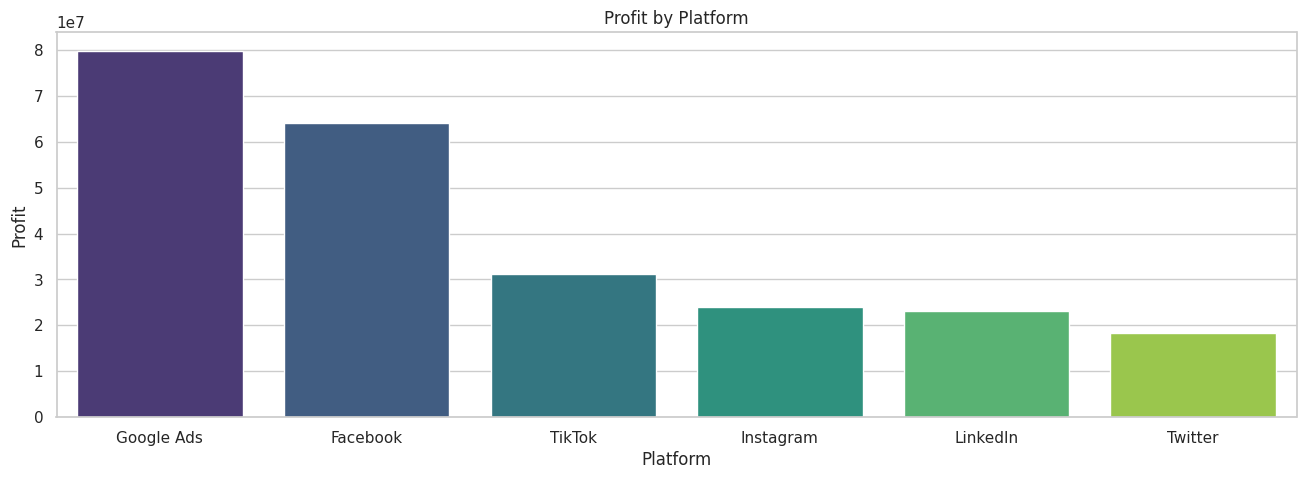

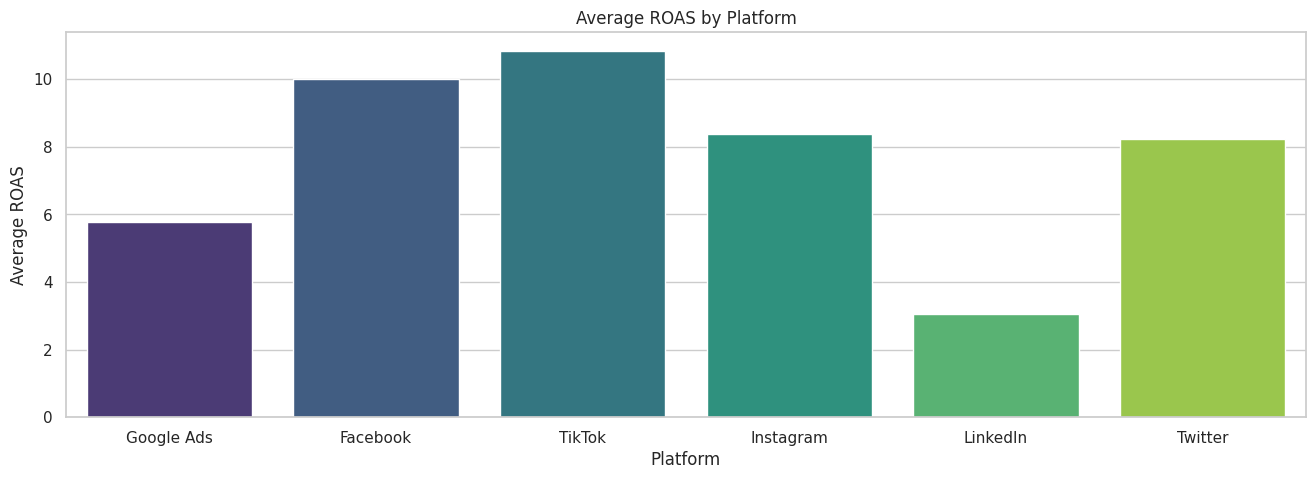

In [90]:
num_platforms = len(platform_perf)
colors = sns.color_palette('viridis', n_colors=num_platforms)

plt.figure(figsize=(16, 5))
sns.barplot(data=platform_perf.reset_index(), x="platform", y="profit", hue="platform", palette=colors, legend=False)
plt.title("Profit by Platform")
plt.xlabel("Platform")
plt.ylabel("Profit")
plt.show()

plt.figure(figsize=(16, 5))
sns.barplot(data=platform_perf.reset_index(), x="platform", y="avg_roas", hue="platform", palette=colors, legend=False)
plt.title("Average ROAS by Platform")
plt.xlabel("Platform")
plt.ylabel("Average ROAS")
plt.show()

In [57]:
# Campaign objective analysis

objective_perf = df.groupby("campaign_objective").agg(
    campaigns=("campaign_id", "nunique"),
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
).sort_values(by="total_profit", ascending=False)

objective_perf

,campaigns,avg_ctr,avg_conv_rate,avg_roas,total_profit
campaign_objective,,,,,
Lead Generation,3563,2.309,4.055,8.756,94572636.330
Conversions,2946,2.318,4.612,9.197,87922429.380
Brand Awareness,2043,2.267,1.987,4.057,30178737.680
App Installs,746,2.454,3.286,6.304,14815924.360
Engagement,702,2.315,2.700,5.651,13212316.930


In [58]:
# Device type analysis

device_perf = df.groupby("device_type").agg(
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
).sort_values(by="total_profit", ascending=False)

device_perf

,avg_ctr,avg_conv_rate,avg_roas,total_profit
device_type,,,,
Desktop,2.680,6.030,12.477,159966814.320
Mobile,2.127,2.169,4.565,64337662.970
Tablet,2.034,3.174,6.008,16397567.390


In [59]:
# Retargeting analysis

retargeting_perf = df.groupby("retargeting_label").agg(
    campaigns=("campaign_id", "nunique"),
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_cpa=("CPA", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
)

retargeting_perf

,campaigns,avg_ctr,avg_conv_rate,avg_cpa,avg_roas,total_profit
retargeting_label,,,,,,
0,7530,2.248,3.142,209.899,6.200,149213082.180
1,2470,2.515,5.174,132.962,11.563,91488962.500


In [60]:
# CTA analysis

cta_perf = df.groupby("has_call_to_action_label").agg(
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
)

cta_perf

,avg_ctr,avg_conv_rate,avg_roas,total_profit
has_call_to_action_label,,,,
0,2.007,2.870,5.823,50356993.620
1,2.450,3.985,8.276,190345051.060


# Audience Analysis

In [61]:
# Gender analysis

gender_perf = df.groupby("target_audience_gender").agg(
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
).sort_values(by="total_profit", ascending=False)

gender_perf

,avg_ctr,avg_conv_rate,avg_roas,total_profit
target_audience_gender,,,,
Female,2.319,3.614,7.548,85751184.670
Male,2.301,3.749,7.380,81350705.940
All,2.325,3.551,7.675,73600154.070


In [62]:
# Age segment analysis

age_perf = df.groupby("target_audience_age").agg(
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
).sort_values(by="total_profit", ascending=False)

age_perf

,avg_ctr,avg_conv_rate,avg_roas,total_profit
target_audience_age,,,,
25-34,2.553,3.614,7.499,74001555.830
35-44,2.151,3.683,7.822,57390640.520
18-24,2.897,3.513,7.359,55623527.090
45-54,1.924,3.748,7.867,31930977.260
55-64,1.767,3.888,7.001,16067852.160
65+,1.509,3.319,6.353,5687491.820


In [63]:
# Interest category analysis

interest_perf = df.groupby("audience_interest_category").agg(
    campaigns=("campaign_id", "nunique"),
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
).sort_values(by="total_profit", ascending=False)

interest_perf.head(10)

,campaigns,avg_ctr,avg_conv_rate,avg_roas,total_profit
audience_interest_category,,,,,
Tech Enthusiasts,2489,2.309,3.467,7.279,57930452.500
Business Professionals,2480,2.301,3.829,7.988,56344975.480
Gamers,1530,2.374,3.561,7.509,41780444.330
Students,1432,2.304,3.775,7.903,35832073.520
Shoppers,1256,2.280,3.738,7.268,32641545.610
Health & Fitness,813,2.330,3.401,6.627,16172553.240


# Creative Analysis

In [64]:
# Creative format analysis

creative_format_perf = df.groupby("creative_format").agg(
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
).sort_values(by="total_profit", ascending=False)

creative_format_perf

,avg_ctr,avg_conv_rate,avg_roas,total_profit
creative_format,,,,
Video,3.111,4.468,9.046,103400276.230
Image,1.837,3.286,7.070,66481492.170
Carousel,2.297,3.289,6.424,34785582.210
Interactive,2.781,3.333,6.582,19634052.640
Story,2.100,3.327,8.300,9177272.550
Text,1.260,3.352,6.431,7223368.880


In [65]:
# Creative emotion analysis

creative_emotion_perf = df.groupby("creative_emotion").agg(
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
).sort_values(by="total_profit", ascending=False)

creative_emotion_perf

,avg_ctr,avg_conv_rate,avg_roas,total_profit
creative_emotion,,,,
Joy,2.304,3.595,7.383,62517124.150
Trust,2.345,3.591,7.414,51540865.290
Urgency,2.318,3.695,7.211,46045113.880
Curiosity,2.294,3.815,7.780,37639886.850
Neutral,2.333,3.581,7.727,21884405.840
Fear,2.284,3.582,8.163,21074648.670


# Time Analysis

In [66]:
# Day of week analysis

day_perf = df.groupby("day_of_week").agg(
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
).reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

day_perf

,avg_ctr,avg_conv_rate,avg_roas,total_profit
day_of_week,,,,
Monday,2.402,3.855,8.151,37693587.930
Tuesday,2.453,3.821,7.963,38049151.840
Wednesday,2.506,4.166,8.794,42879563.460
Thursday,2.529,3.812,8.225,42561137.610
Friday,2.432,3.921,8.750,40037544.390
Saturday,1.912,3.060,5.755,20641841.150
Sunday,1.964,2.876,5.063,18839218.300


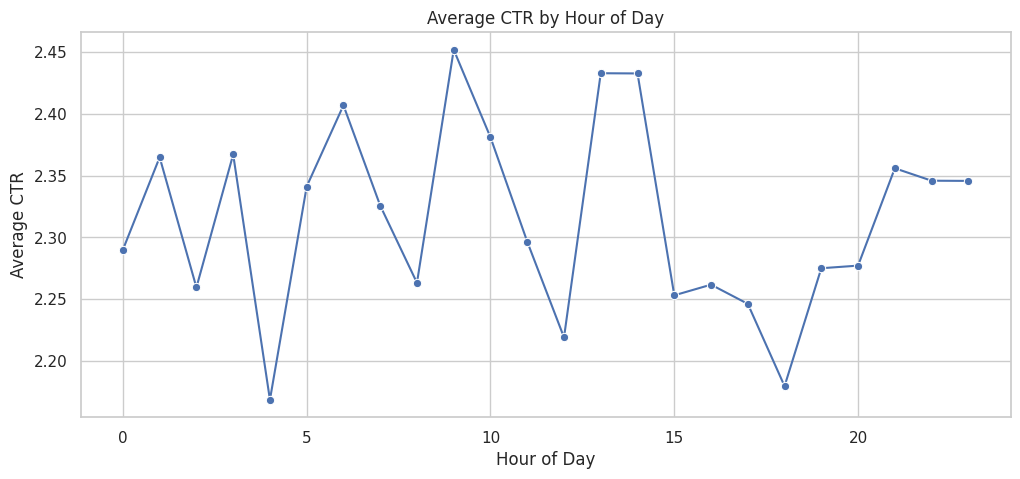

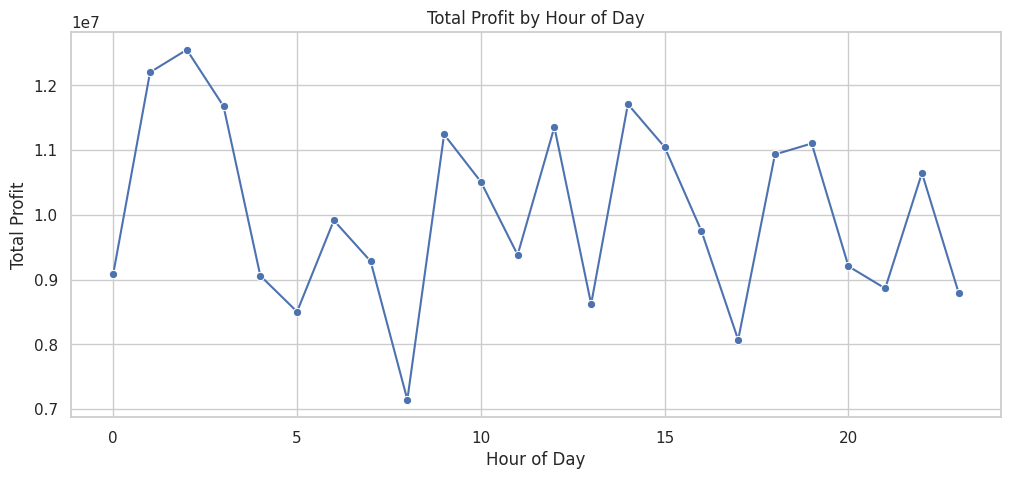

In [67]:
# Hour of day analysis

hour_perf = df.groupby("hour_of_day").agg(
    avg_ctr=("CTR", "mean"),
    avg_conv_rate=("conversion_rate", "mean"),
    avg_roas=("ROAS", "mean"),
    total_profit=("profit", "sum")
).reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hour_perf, x="hour_of_day", y="avg_ctr", marker="o")
plt.title("Average CTR by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average CTR")
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hour_perf, x="hour_of_day", y="total_profit", marker="o")
plt.title("Total Profit by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Profit")
plt.show()

In [68]:
# Monthly trend analysis

monthly_perf = df.groupby(["year", "month_name", "month"]).agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    ad_spend=("ad_spend", "sum"),
    revenue=("revenue", "sum"),
    profit=("profit", "sum")
).reset_index().sort_values(by=["year", "month"])

monthly_perf

,year,month_name,month,impressions,clicks,conversions,ad_spend,revenue,profit
4,2024,January,1,28450059,589765,23217,1670829.590,9492363.160,7821533.570
3,2024,February,2,27007056,577567,23487,1604198.340,12136429.820,10532231.480
7,2024,March,3,26898850,542760,19868,1777918.200,9098779.090,7320860.890
0,2024,April,4,30053459,609008,25344,1874003.530,9615388.170,7741384.640
8,2024,May,5,30400961,542414,20700,1738036.550,9936720.400,8198683.850
6,2024,June,6,27125974,556859,18371,1600274.830,7941396.610,6341121.780
5,2024,July,7,30169125,569198,19254,1591401.770,9484439.250,7893037.480
1,2024,August,8,30961218,575403,19785,1773225.310,8587135.010,6813909.700
11,2024,September,9,31352321,561734,22115,1638332.430,11845283.770,10206951.340
10,2024,October,10,28272400,732479,36233,1933146.140,14902956.720,12969810.580


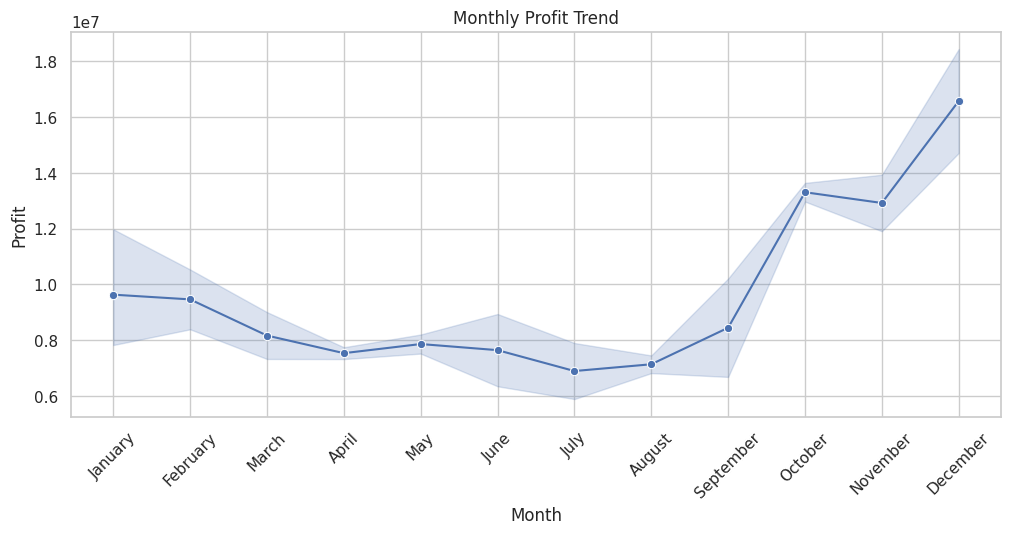

In [69]:
# Monthly trend plot

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_perf, x="month_name", y="profit", marker="o")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

# Correlation Analysis

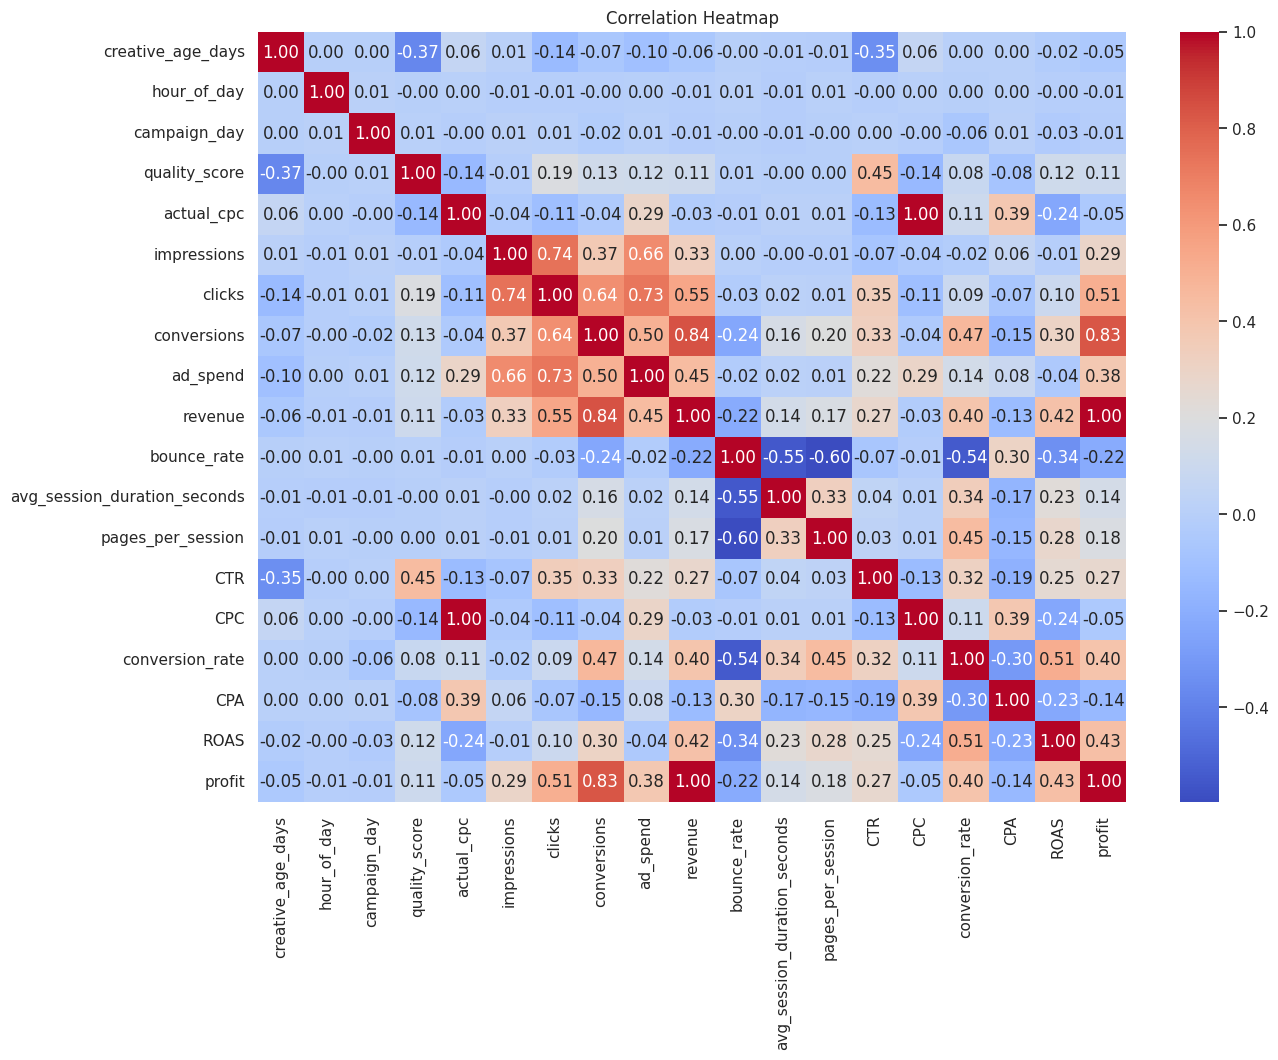

In [70]:
# Correlation heatmap

corr_cols = [
    "creative_age_days", "hour_of_day", "campaign_day", "quality_score",
    "actual_cpc", "impressions", "clicks", "conversions", "ad_spend",
    "revenue", "bounce_rate", "avg_session_duration_seconds",
    "pages_per_session", "CTR", "CPC", "conversion_rate", "CPA", "ROAS", "profit"
]

plt.figure(figsize=(14, 10))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Top / Bottom Campaign Analysis

In [73]:
# Top 10 profitable campaigns

top_campaigns = df[[
    "campaign_id", "platform", "campaign_objective", "industry_vertical",
    "ad_spend", "revenue", "profit", "ROAS", "CTR", "conversion_rate"
]].sort_values(by="profit", ascending=False).head(10)

top_campaigns

,campaign_id,platform,campaign_objective,industry_vertical,ad_spend,revenue,profit,ROAS,CTR,conversion_rate
590,CAMP_00591,TikTok,Brand Awareness,E-commerce,49999.500,2800397.430,2750397.930,56.010,4.878,18.344
3997,CAMP_03998,Facebook,Lead Generation,SaaS,37819.180,2231447.670,2193628.490,59.000,5.553,15.357
8878,CAMP_08879,Google Ads,Lead Generation,Finance,49994.010,2089944.930,2039950.920,41.800,2.877,22.903
5003,CAMP_05004,Google Ads,Lead Generation,Finance,48333.040,1990489.740,1942156.700,41.180,4.062,25.000
7528,CAMP_07529,Twitter,Conversions,SaaS,47497.520,1822157.700,1774660.180,38.360,6.220,7.870
6646,CAMP_06647,Instagram,App Installs,Healthcare,14970.450,1750031.400,1735060.950,116.900,3.316,20.250
8552,CAMP_08553,Facebook,Conversions,Finance,29591.760,1389697.140,1360105.380,46.960,7.644,9.515
3870,CAMP_03871,TikTok,Lead Generation,Healthcare,19998.880,1258308.080,1238309.200,62.920,3.764,11.974
4030,CAMP_04031,Facebook,Conversions,Finance,30831.070,1263292.710,1232461.640,40.970,4.172,17.001
6843,CAMP_06844,TikTok,Brand Awareness,SaaS,49997.980,1234132.790,1184134.810,24.680,7.965,12.729


In [74]:
# Bottom 10 campaigns

bottom_campaigns = df[[
    "campaign_id", "platform", "campaign_objective", "industry_vertical",
    "ad_spend", "revenue", "profit", "ROAS", "CTR", "conversion_rate"
]].sort_values(by="profit", ascending=True).head(10)

bottom_campaigns

,campaign_id,platform,campaign_objective,industry_vertical,ad_spend,revenue,profit,ROAS,CTR,conversion_rate
2554,CAMP_02555,LinkedIn,Brand Awareness,Education,49996.960,13057.120,-36939.840,0.260,1.723,1.342
9031,CAMP_09032,LinkedIn,Conversions,Gaming,39468.000,3590.750,-35877.250,0.090,3.244,0.692
3266,CAMP_03267,Google Ads,Lead Generation,E-commerce,36893.260,3589.690,-33303.570,0.100,1.524,0.413
6606,CAMP_06607,LinkedIn,Brand Awareness,SaaS,49993.060,16766.160,-33226.900,0.340,3.309,0.506
5954,CAMP_05955,Google Ads,Brand Awareness,Education,47114.200,17722.240,-29391.960,0.380,3.227,0.645
82,CAMP_00083,LinkedIn,Lead Generation,E-commerce,37596.360,8508.890,-29087.470,0.230,3.373,0.994
6310,CAMP_06311,LinkedIn,Lead Generation,Healthcare,49998.060,22549.200,-27448.860,0.450,1.103,1.724
7310,CAMP_07311,LinkedIn,Engagement,Finance,39830.830,12394.710,-27436.120,0.310,1.360,0.547
4838,CAMP_04839,Google Ads,Brand Awareness,E-commerce,36056.250,11467.540,-24588.710,0.320,1.923,0.811
7298,CAMP_07299,LinkedIn,Lead Generation,E-commerce,44610.380,20572.750,-24037.630,0.460,4.076,1.331


# Profitability Analysis

In [77]:
#Profitable vs loss campaigns

profit_status_summary = df["profit_status"].value_counts()
profit_status_summary

,count
profit_status,
profitable,7831
unprofitable,2169


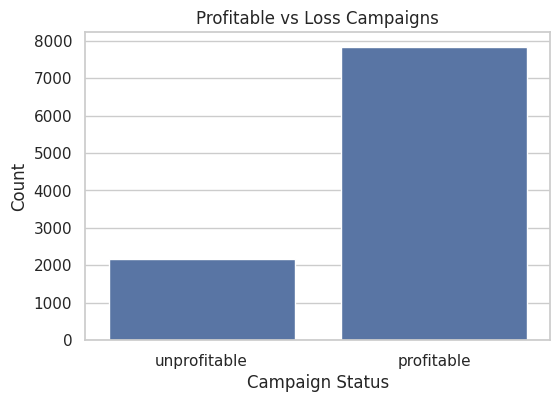

In [78]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="profit_status")
plt.title("Profitable vs Loss Campaigns")
plt.xlabel("Campaign Status")
plt.ylabel("Count")
plt.show()

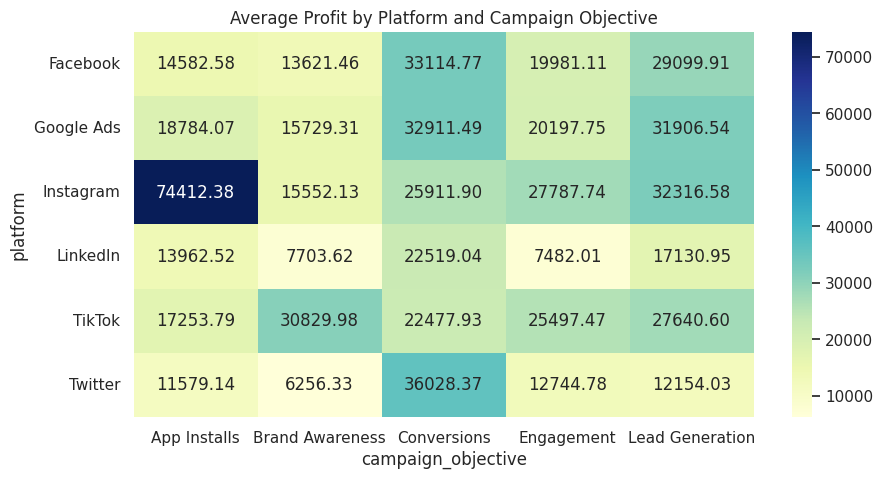

In [79]:
# Profitability by platform and objective

pivot_profit = pd.pivot_table(
    df,
    index="platform",
    columns="campaign_objective",
    values="profit",
    aggfunc="mean"
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_profit, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Profit by Platform and Campaign Objective")
plt.show()

# Outlier Analysis


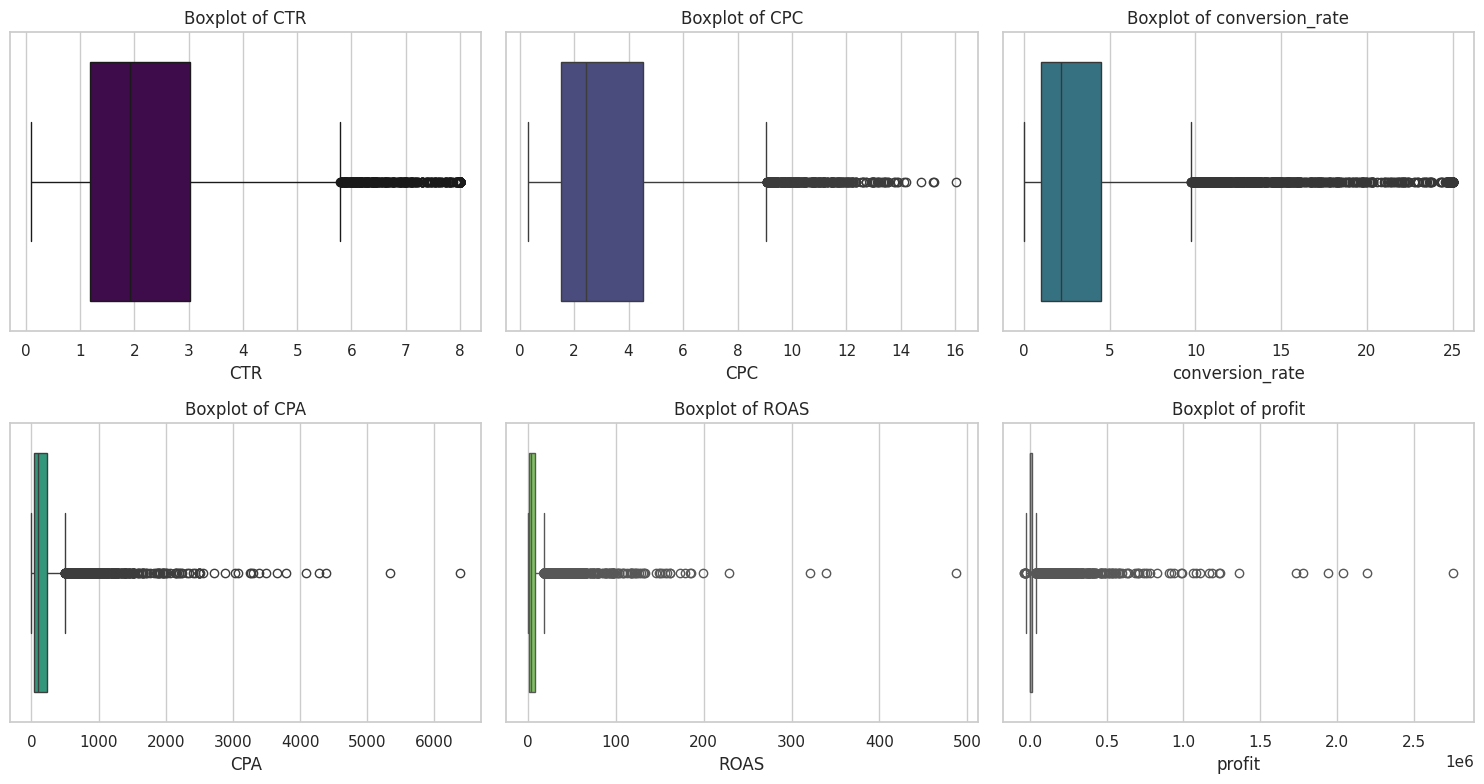

In [81]:
import matplotlib.cm as cm

box_cols = ["CTR", "CPC", "conversion_rate", "CPA", "ROAS", "profit"]

n_cols = 3
n_rows = (len(box_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

colors = cm.viridis(np.linspace(0, 1, len(box_cols)))

for i, col in enumerate(box_cols):
    sns.boxplot(x=df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Final Business Insight Cell

In [83]:
print("Top Platform by Profit:\n", platform_perf[["profit"]].head(1))
print("\nTop Campaign Objective by Profit:\n", objective_perf[["total_profit"]].head(1))
print("\nTop Device Type by Profit:\n", device_perf[["total_profit"]].head(1))
print("\nTop Audience Age Group by Profit:\n", age_perf[["total_profit"]].head(1))
print("\nTop Creative Format by Profit:\n", creative_format_perf[["total_profit"]].head(1))
print("\nTop Creative Emotion by Profit:\n", creative_emotion_perf[["total_profit"]].head(1))

Top Platform by Profit:
                  profit
platform               
Google Ads 79841954.440

Top Campaign Objective by Profit:
                     total_profit
campaign_objective              
Lead Generation     94572636.330

Top Device Type by Profit:
              total_profit
device_type              
Desktop     159966814.320

Top Audience Age Group by Profit:
                      total_profit
target_audience_age              
25-34                74001555.830

Top Creative Format by Profit:
                  total_profit
creative_format              
Video           103400276.230

Top Creative Emotion by Profit:
                   total_profit
creative_emotion              
Joy               62517124.150


Final Conclusion:

1. Identify the platform with the highest profit and ROAS.
2. Identify the campaign objective with strongest business return.
3. Check whether retargeting campaigns outperform non-retargeting campaigns.
4. Find the most effective audience segment by age, gender, and interest.
5. Identify best-performing creative format and emotion.
6. Find the best day and hour for campaign performance.
7. Use low-ROAS and low-profit patterns to improve future ad spending.

Recommendation:
Focus future budget on segments with high ROAS, high conversion rate, and strong profit.
Reduce spending on low-profit platform-objective combinations.